<a href="https://colab.research.google.com/github/maurishi09/maurishi09/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/Assignment 1.csv")

print(df.head())
print(df.info())

                      Game Name       Genre         Platform  Release Year  \
0     Sekiro: Shadows Die Twice      Sports  Nintendo Switch          2014   
1                       Control      Puzzle  Nintendo Switch          2000   
2                      Among Us    Strategy  Nintendo Switch          2007   
3  Call of Duty: Modern Warfare     Stealth      PlayStation          2005   
4             League of Legends  Simulation               PC          2021   

   User Rating  
0     9.654719  
1     3.457386  
2     5.367622  
3     1.240325  
4     3.535476  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Game Name     5000 non-null   object 
 1   Genre         5000 non-null   object 
 2   Platform      5000 non-null   object 
 3   Release Year  5000 non-null   int64  
 4   User Rating   5000 non-null   float64
dtypes: float64(1), in

In [3]:
print(df.isnull().sum())

Game Name       0
Genre           0
Platform        0
Release Year    0
User Rating     0
dtype: int64


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
df = df.drop_duplicates()

In [6]:
df['Genre'] = df['Genre'].str.strip().str.title()

In [7]:
df['Platform'] = df['Platform'].str.strip().str.title()

In [8]:
df['Decade'] = (df['Release Year'] // 10) * 10

In [9]:
genre_rating = df.groupby('Genre')['User Rating'].mean().sort_values(ascending=False)

print(genre_rating)

Genre
Survival        5.831934
Horror          5.629845
Simulation      5.626343
Action          5.603556
Sports          5.561171
Fighting        5.513218
Puzzle          5.511684
Adventure       5.510799
Shooter         5.509610
Strategy        5.483330
Racing          5.463723
Stealth         5.423839
Role-Playing    5.412653
Platformer      5.254660
Name: User Rating, dtype: float64


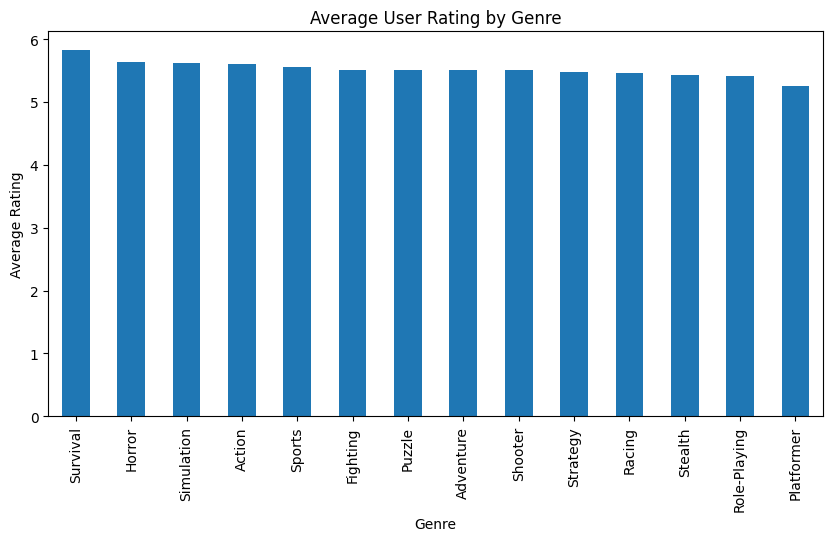

In [10]:
plt.figure(figsize=(10,5))

genre_rating.plot(kind='bar')

plt.title("Average User Rating by Genre")
plt.ylabel("Average Rating")
plt.show()

In [11]:
platform_rating = df.groupby('Platform')['User Rating'].mean().sort_values(ascending=False)

print(platform_rating)

Platform
Pc                 5.599444
Xbox               5.531032
Playstation        5.523658
Nintendo Switch    5.523076
Mobile             5.441895
Name: User Rating, dtype: float64


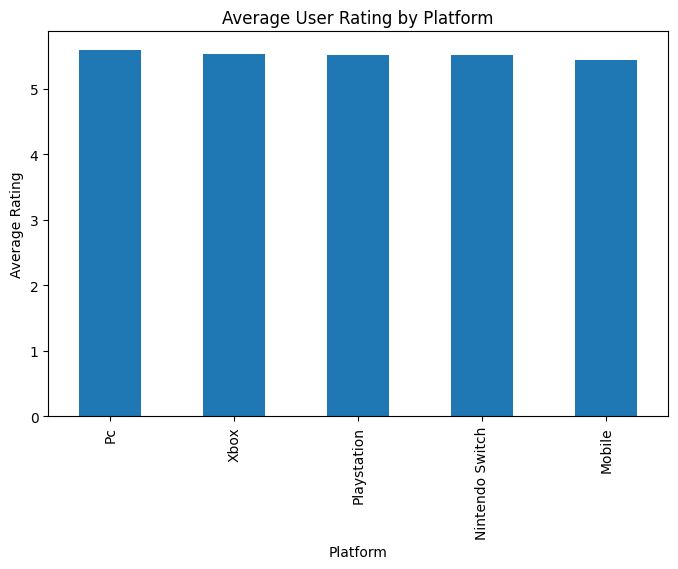

In [12]:
plt.figure(figsize=(8,5))

platform_rating.plot(kind='bar')

plt.title("Average User Rating by Platform")
plt.ylabel("Average Rating")
plt.show()

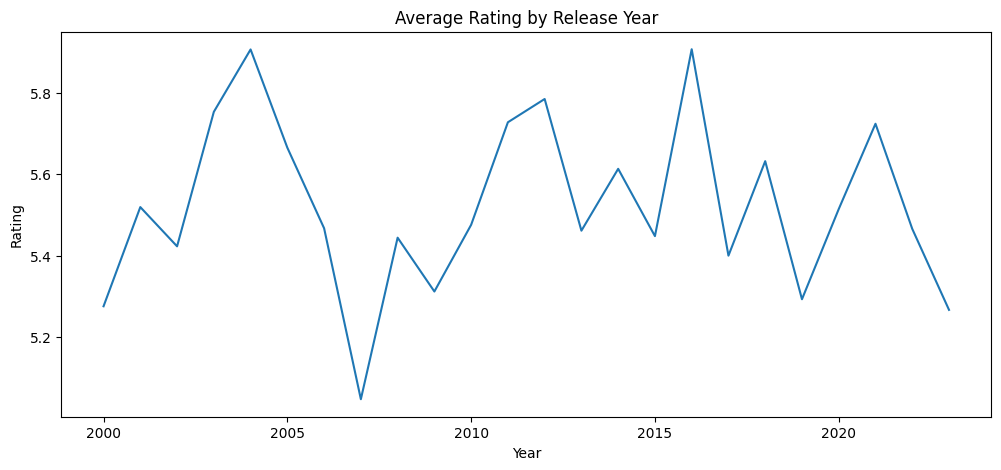

In [13]:
year_rating = df.groupby('Release Year')['User Rating'].mean()

plt.figure(figsize=(12,5))

plt.plot(year_rating.index, year_rating.values)

plt.title("Average Rating by Release Year")

plt.xlabel("Year")
plt.ylabel("Rating")

plt.show()

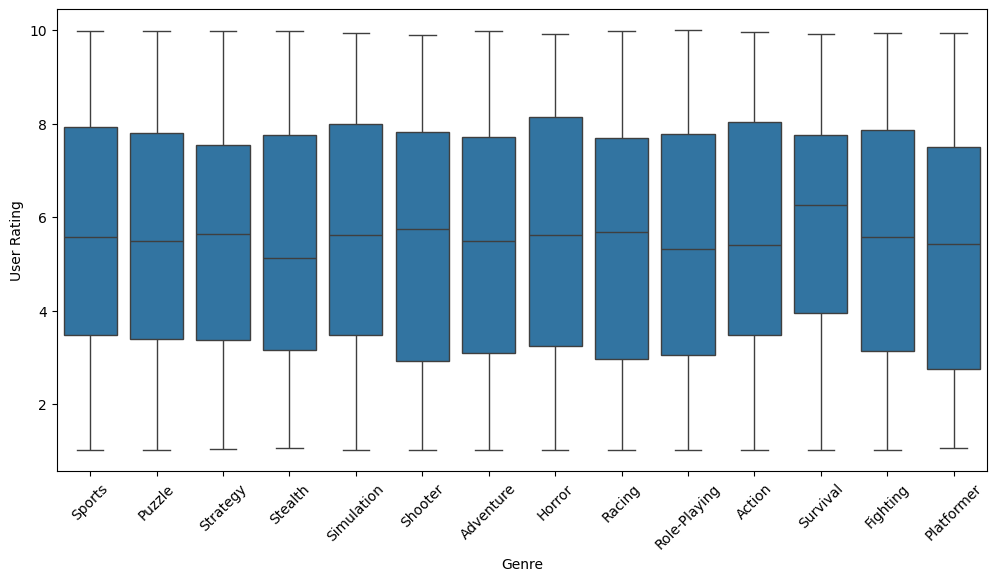

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(x='Genre',
            y='User Rating',
            data=df)

plt.xticks(rotation=45)

plt.show()

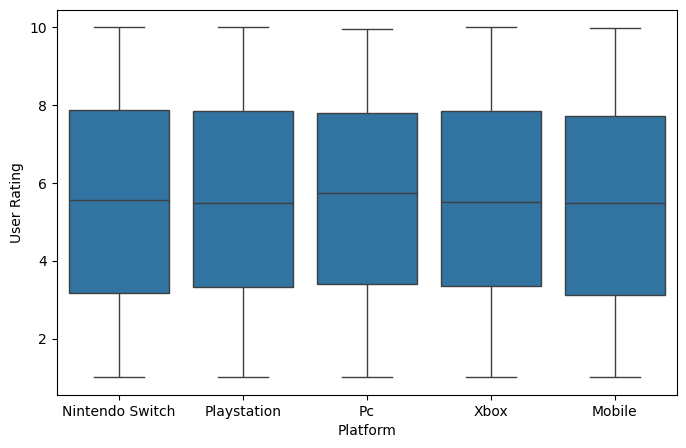

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Platform',
            y='User Rating',
            data=df)

plt.show()

In [16]:
top_genres = df.groupby('Genre')['User Rating'].mean()\
               .sort_values(ascending=False)\
               .head(5)

print(top_genres)

Genre
Survival      5.831934
Horror        5.629845
Simulation    5.626343
Action        5.603556
Sports        5.561171
Name: User Rating, dtype: float64


In [17]:
top_platforms = df.groupby('Platform')['User Rating'].mean()\
                  .sort_values(ascending=False)\
                  .head(5)

print(top_platforms)

Platform
Pc                 5.599444
Xbox               5.531032
Playstation        5.523658
Nintendo Switch    5.523076
Mobile             5.441895
Name: User Rating, dtype: float64


In [18]:
#3. Advanced Analysis

decade_rating = df.groupby('Decade')['User Rating'].mean()

print(decade_rating)

Decade
2000    5.481758
2010    5.581768
2020    5.492709
Name: User Rating, dtype: float64


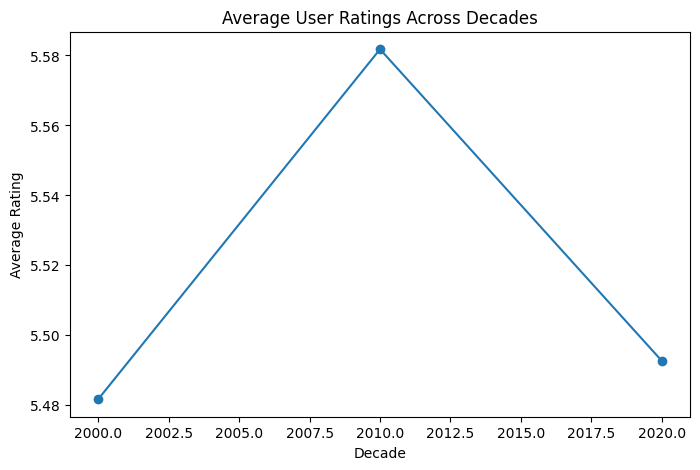

In [19]:
plt.figure(figsize=(8,5))

plt.plot(decade_rating.index,
         decade_rating.values,
         marker='o')

plt.title("Average User Ratings Across Decades")

plt.xlabel("Decade")
plt.ylabel("Average Rating")

plt.show()

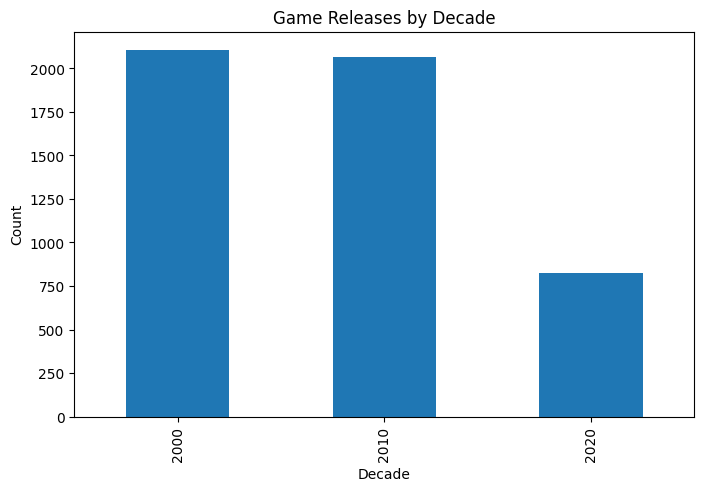

In [20]:
games_per_decade = df.groupby('Decade').size()

plt.figure(figsize=(8,5))

games_per_decade.plot(kind='bar')

plt.title("Game Releases by Decade")

plt.ylabel("Count")

plt.show()

In [21]:
platform_groups = [
    group["User Rating"].values
    for name, group in df.groupby("Platform")
]

f_stat, p_value = f_oneway(*platform_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.47019436414904814
P-value: 0.7576711464074468


In [22]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [23]:
corr_df = df.copy()

le_genre = LabelEncoder()
le_platform = LabelEncoder()

corr_df['Genre'] = le_genre.fit_transform(corr_df['Genre'])
corr_df['Platform'] = le_platform.fit_transform(corr_df['Platform'])

In [24]:
corr_matrix = corr_df.corr(numeric_only=True)

print(corr_matrix)

                 Genre  Platform  Release Year  User Rating    Decade
Genre         1.000000 -0.004754     -0.023437     0.010851 -0.037414
Platform     -0.004754  1.000000      0.005102     0.009651  0.001248
Release Year -0.023437  0.005102      1.000000     0.000177  0.917514
User Rating   0.010851  0.009651      0.000177     1.000000  0.006851
Decade       -0.037414  0.001248      0.917514     0.006851  1.000000


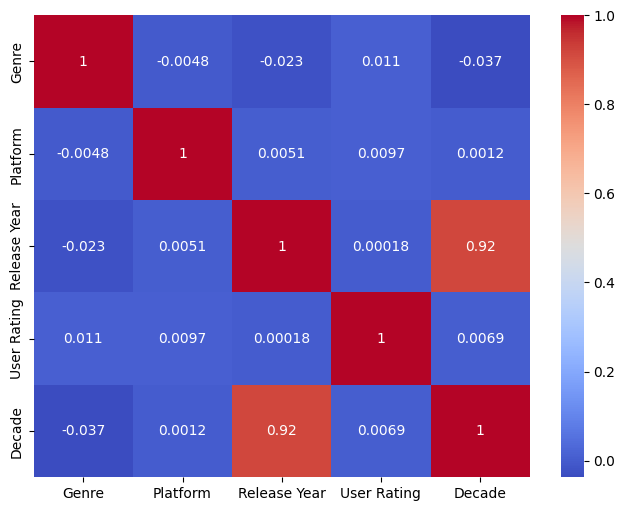

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.show()

In [26]:
#Machine Learning

ml_df = df.copy()

genre_encoder = LabelEncoder()
platform_encoder = LabelEncoder()

ml_df['Genre'] = genre_encoder.fit_transform(ml_df['Genre'])
ml_df['Platform'] = platform_encoder.fit_transform(ml_df['Platform'])

In [27]:
X = ml_df[['Genre',
           'Platform',
           'Release Year']]

y = ml_df['User Rating']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [30]:
predictions = model.predict(X_test)

In [31]:
print("MAE:",
      mean_absolute_error(y_test, predictions))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, predictions)))

print("R² Score:",
      r2_score(y_test, predictions))

MAE: 2.426560458206299
RMSE: 2.914329229589154
R² Score: -0.25969147998795594


In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

        Feature  Importance
2  Release Year    0.387341
0         Genre    0.352962
1      Platform    0.259697


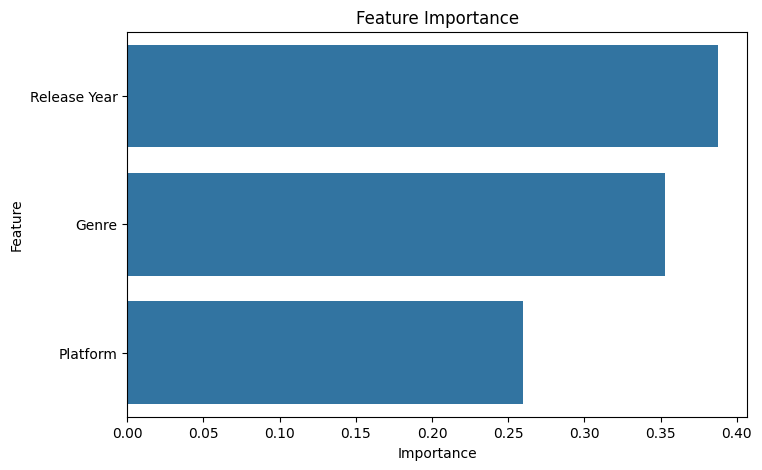

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()